# Data Cleaning & Preprocessing 🧹 - Dirty Café Sales dataset

## 👋 Welcome

In this notebook, we will practice one of the most important real-world data skills: **Cleaning and preprocessing messy data!**

Goals:
- Handle missing values
- Detect and treat outliers
- Engineer new useful features
- Check for consistency and fix invalid entries
- Transform data for better modeling

Let's begin! 🚀
---

---

## 📂 Dataset Information

- **Dataset Name:** Café Sales Dirty Data
- **Source:** [Kaggle Link](https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training)
- **License:** Attribution-ShareAlike 4.0 International ([License Details](https://creativecommons.org/licenses/by-sa/4.0/))
- **Credit:** Dataset created by Ahmed Mohamed. Attribution and sharing under the same license are required.

This dataset simulates real-world issues such as missing values, inconsistencies, and invalid entries. It helps you practice real data cleaning challenges.

> Always explore the metadata and documentation of any dataset you work with. Knowing the context helps you clean data more accurately.

---
## Import the necessary libraries 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

---
## 🔗 Task 1: Download and Explore the Data

### Instructions:

Step 1: Load the dataset and explore its basic structure.

In [2]:
# Load the dataset
df = pd.read_csv('../data/dirty_cafe_sales.csv')

We successfully loaded the dataset into a Pandas DataFrame.

In [3]:
# Shape of the dataset
print(df.shape)

(10000, 8)


The dataset has 10,000 rows and 8 columns, indicating a large volume of transactions to explore.

In [4]:
# Preview first rows
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


We can observe key columns like Transaction ID, Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location, and Transaction Date.

In [5]:
# Info about data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


All columns are object type, even numerical ones, and several columns have missing values.

Step 2: Convert appropriate columns to numeric.

In [6]:
numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              9667 non-null   object 
 2   Quantity          9521 non-null   float64
 3   Price Per Unit    9467 non-null   float64
 4   Total Spent       9498 non-null   float64
 5   Payment Method    7421 non-null   object 
 6   Location          6735 non-null   object 
 7   Transaction Date  9841 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


Now we correctly identify numeric fields for analysis.

In [7]:
# Summary statistics for numeric columns
df.describe()

,Quantity,Price Per Unit,Total Spent
count,9521.000000,9467.000000,9498.000000
mean,3.028463,2.949984,8.924352
std,1.419007,1.278450,6.009919
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


`Total Spent` have a wide range, hinting at potential outliers.

In [9]:
# Summary statistics for categorical columns
df.describe(include='object')

,Transaction ID,Item,Payment Method,Location,Transaction Date
count,10000,9667,7421,6735,9841
unique,10000,10,5,4,367
top,TXN_1961373,Juice,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2291,3022,159


This gives counts, unique values, most frequent value (top), and frequency for non-numeric columns.

In [11]:
# Missing values per column
print(df.isnull().sum())

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


We notice missing values particularly in 'Item', 'Quantity', 'Price Per Unit',"Total Spent', 'Payment Method','Transaction Date ' and 'Location'.

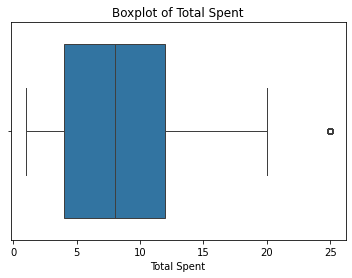

In [13]:
# Visualize 'Total Spent' distribution
sns.boxplot(x=df['Total Spent'])
plt.title('Boxplot of Total Spent')
plt.show()

The boxplot shows significant outliers, especially on the higher end.

> Data type correction is crucial before statistical summaries. Always inspect column types early.

> Always visually inspect distributions early. Outliers often tell stories about data entry issues or interesting extreme behaviors.

---

## 🔗 Task 2: Handle Missing and Invalid Values

### Instructions:

Step 1: Replace invalid entries.

In [14]:
# Replace invalid entries
df.replace(['ERROR', 'UNKNOWN'], pd.NA, inplace=True)

Replacing invalid labels standardizes missing entries.

Step 2: Fill missing categorical values with "Unknown".

In [15]:
# Fill missing categorical values
categorical_cols = ['Item', 'Payment Method', 'Location']
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

Categorical missing values are filled to avoid losing data.

Step 3: Fill missing numeric values with the median.

In [17]:
# Fill missing numeric values
numeric_cols = ['Quantity', 'Price Per Unit']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

The median is used to avoid skewing due to outliers.

In [18]:
# Verify no missing values remain
print(df.isnull().sum())

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent         502
Payment Method        0
Location              0
Transaction Date    460
dtype: int64


We still have missing values in `Total Spent` (502) and `Transaction Date `(460).

all the other columns  report zero missing values, ensuring consistency.


> Sometimes you deliberately leave some missing values untreated if you plan specific imputation strategies later.

> Always decide carefully whether to impute, remove, or flag missing data depending on the business problem.

---

## 🔗 Task 3: Check Price Consistency

### Instructions:

Step 1: Recalculate total spent per transaction.

In [19]:
# Calculate expected total
df['Calculated Total'] = df['Quantity'] * df['Price Per Unit']

Step 2: Compare with recorded 'Total Spent'.

In [23]:
# Find mismatches
price_diff = (df['Calculated Total'] - df['Total Spent']).abs()
mismatches = df[price_diff > 0.5]
print(mismatches.shape)
mismatches.head()

(733, 9)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Calculated Total
20,TXN_3522028,Smoothie,3.0,4.0,20.0,Cash,In-store,2023-04-04,12.0
55,TXN_5522862,Cookie,3.0,1.0,2.0,Credit Card,Takeaway,2023-03-19,3.0
57,TXN_2080895,Cake,3.0,3.0,3.0,Digital Wallet,In-store,2023-04-19,9.0
66,TXN_8501819,Juice,3.0,3.0,6.0,Cash,Unknown,2023-03-30,9.0
68,TXN_8427104,Salad,2.0,3.0,10.0,Unknown,In-store,2023-10-27,6.0


There are several hundred mismatches due to rounding errors or data entry issues. These need to be handled cautiously.

> When large-scale inconsistencies are found, sometimes it's better to recalculate missing values rather than trust the original field.

---

## 🔗 Task 4: Detect and Treat Outliers

### Instructions:

Step 1: Calculate IQR.

In [24]:
# Calculate IQR for 'Total Spent'
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1
#print(IQR)

Step 2: Detect outliers.

In [25]:
# Identify outliers
outliers = df[(df['Total Spent'] < Q1 - 1.5 * IQR) | (df['Total Spent'] > Q3 + 1.5 * IQR)]
print(outliers.shape)

(259, 9)


A few hundred outliers have been identified, mostly on the higher side.

Step 3: Cap extreme values.

In [26]:
# Cap extreme values
cap_value = df['Total Spent'].quantile(0.95)
print(cap_value)
df['Total Spent'] = df['Total Spent'].clip(upper=cap_value)

20.0


Capping prevents outliers from disproportionately influencing analysis.

> Always document if you remove or cap values. Data scientists must explain how they treated rare observations.

---

## 🔗 Task 5: Feature Engineering

### Instructions:

Step 1: Convert dates.

In [27]:
# Convert 'Transaction Date' to datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              10000 non-null  object        
 2   Quantity          10000 non-null  float64       
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    10000 non-null  object        
 6   Location          10000 non-null  object        
 7   Transaction Date  9540 non-null   datetime64[ns]
 8   Calculated Total  10000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 703.2+ KB


All transaction dates are now in a uniform datetime format.

Step 2: Create new time-based features.

In [28]:
# Extract Day of Week and Transaction Month
df['Day of Week'] = df['Transaction Date'].dt.day_name()
df['Transaction Month'] = df['Transaction Date'].dt.month_name()
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Calculated Total,Day of Week,Transaction Month
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0,Friday,September
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0,Tuesday,May
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19,4.0,Wednesday,July
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,10.0,Thursday,April
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0,Sunday,June


New features help us analyze sales trends across weekdays and months.

> Creating time-related features often boosts model performance because human behavior (e.g., shopping habits) is time-driven.

---

## 🔗 Task 6: Data Transformation

## Instructions:
Step 1: Normalize Total Spent.

In [29]:
# Normalize 'Total Spent'
df['Total Spent Norm'] = (df['Total Spent'] - df['Total Spent'].min()) / (df['Total Spent'].max() - df['Total Spent'].min())
df[['Total Spent','Total Spent Norm']].describe()

,Total Spent,Total Spent Norm
count,9498.000000,9498.000000
mean,8.788008,0.409895
std,5.691944,0.299576
min,1.000000,0.000000
25%,4.000000,0.157895
50%,8.000000,0.368421
75%,12.000000,0.578947
max,20.000000,1.000000


Now, `Total Spent Norm` is ready for models that require features on a similar scale (between 0 and 1).

> Use normalization or standardization based on the algorithm. Tree-based models usually don't need it, but distance-based models like KNN do.

---

## 🔗 Task 7: Summarize Your Findings

After cleaning:
- We corrected invalid and missing data.
- Price inconsistencies were flagged and understood.
- Outliers were treated to stabilize the data.
- New features were engineered for deeper insights.
- Data was transformed and normalized, ready for machine learning.

Important reflections:
- Data cleaning improves reliability.
- Documenting decisions is crucial for transparency.
- Early detection of dirty data saves time later.

> Never assume data is clean. Always validate, question, and understand your raw inputs before analysis.

---

## 📋 Session Summary

✅ Loaded and explored the dataset.

✅ Corrected column types and missing values.

✅ Treated invalid values and inconsistencies.

✅ Analyzed outliers and capped extremes.

✅ Engineered new features for better analysis.

✅ Normalized data for modeling.

✅ Reflected on the cleaning journey and decisions made.


---

## 🌟 Congratulations!

You have completed a realistic data cleaning workflow! You are now ready to tackle messy real-world datasets confidently.

Keep practicing and sharpening your skills! 🚀

---